# Import packages and configuration

In [2]:
import nifty.re as jft

import numpy as np

import jax
import jax.random as random

%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100

jax.config.update("jax_enable_x64", True)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


---
# Looking at the data

In [3]:
x, d = np.loadtxt("data.txt", delimiter="\t", skiprows=1, unpack=True)

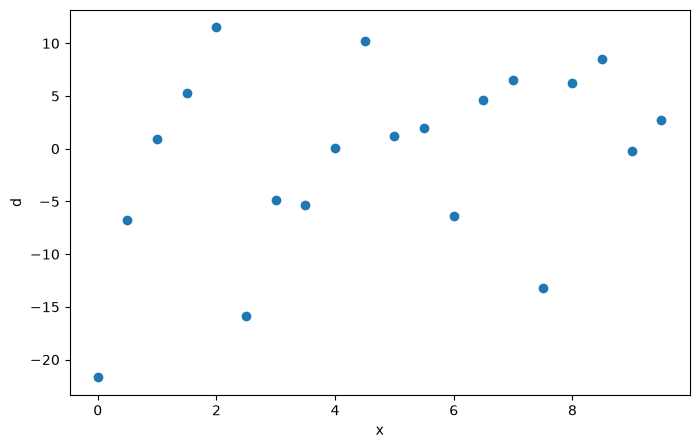

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(x, d)
plt.xlabel("x")
plt.ylabel("d")
plt.show()

---
# Doing linear regression with Bayes

$$ \vec{y} = a \vec{x} + b\vec{1}, $$

with 
$$a, b \in \mathbb{R}$$
$$\vec{x}, \vec{y} \in \mathbb{R}^{N}$$

## Model for the slope $a$

***Prior knowledge:*** \
We know that $a > 0$ with a value of 4 and an uncertainty of 3.

In [5]:
a = jft.LogNormalPrior(mean = 4, std = 3, name = "a_input")

In [6]:
print(a.domain)

{'a_input': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>)}


In [7]:
print(a.target)

ShapeDtypeStruct(shape=(), dtype=float64)


In [8]:
a_test_input = {"a_input": 0.0}
res = a(a_test_input)
print(res)

3.2


Text(0.5, 1.0, 'a')

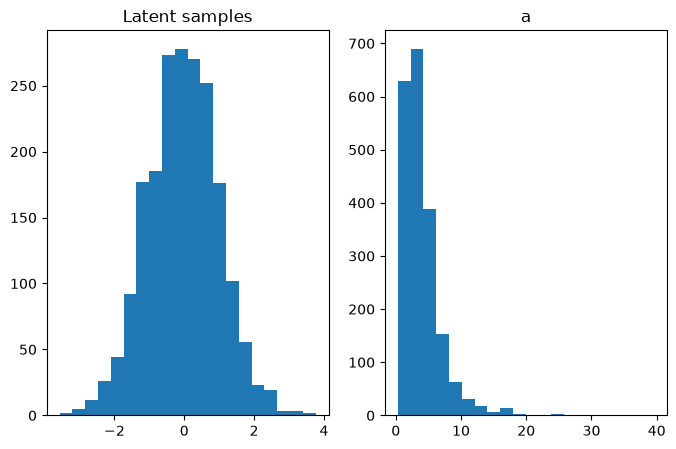

In [9]:
seed = 42
key = random.PRNGKey(seed)

latent_sample_list = []
a_sample_list = []

for i in range(2000):
    key, subkey = random.split(key, 2)
    xi = jft.random_like(subkey, a.domain)
    a_sample = a(xi)

    latent_sample_list.append(xi["a_input"])
    a_sample_list.append(a_sample)

fig, ax = plt.subplots(1, 2, figsize=(8, 5))
ax[0].hist(latent_sample_list, bins=20)
ax[0].set_title("Latent samples")
ax[1].hist(a_sample_list, bins=20)
ax[1].set_title("a")

## Model for the intercept $b$

***Prior knowledge:*** \
We know that $b$ has a value of 0 and an uncertainty of 3.

In [10]:
b = jft.NormalPrior(mean = 0, std = 3, name = "b_input")

print(b.domain)
print(b.target)

{'b_input': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>)}
ShapeDtypeStruct(shape=(), dtype=float64)


## Forward model for linear regression

$$\vec{y}(\xi_a ,\xi_b) = a(\xi_a)\vec{x} + b(\xi_b)\vec{1}$$

In [11]:
class LinearModel(jft.Model):
    def __init__(self, x, a, b):
        self.x = x
        self.a = a
        self.b = b
        super().__init__(domain = a.domain | b.domain, white_init = True)

    def __call__(self, inp):
        return self.x * self.a(inp) + self.b(inp)

    

my_model = LinearModel(x, a, b)

print(my_model.domain)
print(a.domain | b.domain)

{'a_input': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>), 'b_input': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>)}
{'a_input': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>), 'b_input': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>)}


Text(0, 0.5, 'd')

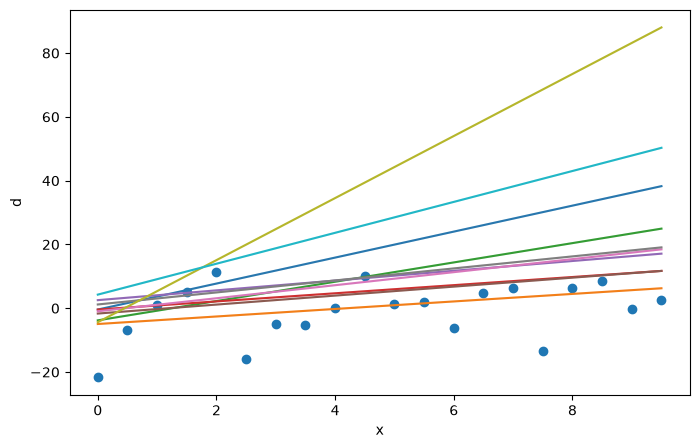

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(x, d)

for i in range(10):
    key, subkey = random.split(key)
    latent_sample = jft.random_like(subkey, my_model.domain)
    y_sample = my_model(latent_sample)
    plt.plot(x, y_sample)

    plt.plot(x, y_sample, color="gray", alpha=0.1)
plt.xlabel("x")
plt.ylabel("d")



## Accounting for noisy measurements
$$\vec{d} = \vec{y}(\xi_a ,\xi_b) + \vec{n} $$
with 
$$\vec{d}, \vec{n} \in \mathbb{R}^{N}$$

***Prior knowledge:*** \
We know that $\vec{n}$ is normal distributed noise with mean 0 and standard deviation 10.

### Likelihood
$$ P(d|\xi_a, \xi_b) = P(d|y(\xi_a,\xi_b)) = P(n = d - y(\xi_a,\xi_b)) = G(d-y, 10^2).$$

### Likelihood Hamiltonian (used in NIFTy)

$$H(d|\xi_a, \xi_b) = - \ln(P(d|\xi_a, \xi_b)).$$

In [13]:
cov = 10 ** 2
noise_cov = lambda x: x * cov
noice_cov_inv = lambda x: x / cov
lh = jft.Gaussian(data = d, noise_cov_inv=noice_cov_inv).amend(my_model)

print(lh.domain)
print(lh.target)

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


{'a_input': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>), 'b_input': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>)}
ShapeDtypeStruct(shape=(), dtype=float64)


---
# Inference

In [14]:
key, subkey = random.split(key, 2)
init_pos = lh.init(subkey)
print(init_pos)
init_pos = jft.Vector(init_pos)
print(init_pos)

{'a_input': Array(0.62455523, dtype=float64), 'b_input': Array(1.44737671, dtype=float64)}
Vector(
	{'a_input': Array(0.62455523, dtype=float64),
	 'b_input': Array(1.44737671, dtype=float64)}
)


In [15]:
n_samples = 4
n_vi_iterations = 6

In [16]:
key, sampling_key = random.split(key, 2)
draw_linear_kwargs = dict(cg_name = None, cg_kwargs = dict(absdelta = 1e-5 * jft.size(lh.domain), maxiter = 100))

kl_kwargs = dict(minimize_kwargs = dict(name=None, xtol= 1e-4, maxiter = 35))

sample_mode = "linear_resample"

In [17]:
samples, state = jft.optimize_kl(likelihood=lh, 
                                 position_or_samples = init_pos,

                                   n_samples=n_samples,
                                     n_total_iterations=n_vi_iterations,
                                       key=sampling_key, draw_linear_kwargs=draw_linear_kwargs, 
                                       kl_kwargs=kl_kwargs, sample_mode=sample_mode)

<frozen genericpath>:39: RuntimeWarning: bool is used as a file descriptor
OPTIMIZE_KL: Starting 0001
OPTIMIZE_KL: Iteration 0001 E:+9.4999e+00
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 7
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:    0.72±   0.082, avg:    -0.21±    0.17, #dof:     20'

OPTIMIZE_KL: Prior residual(s):
a_input                 :: 'reduced Chi²:     2.5±    0.23, avg:     -1.6±   0.071, #dof:      1'
b_input                 :: 'reduced Chi²:     2.0±     1.6, avg:     -1.3±    0.59, #dof:      1'


OPTIMIZE_KL: Starting 0002
OPTIMIZE_KL: Iteration 0002 E:+1.1928e+01
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 11
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:    0.79±    0.26, avg:    -0.18±    0.27, #dof:     20'

OPTIMIZE_KL: Prior residual(s):
a_input                 :: 'reduced Chi²:     6.3±     5.0, avg:     -2.3±     1.1, #dof:      1'
b_input                 :: 're

In [18]:
a_samples = tuple(a(s) for s in samples)
b_samples = tuple(b(s) for s in samples)
y_samples = tuple(my_model(s) for s in samples)


In [19]:
a_mean = jft.mean(a_samples)
b_mean = jft.mean(b_samples)
y_mean = jft.mean(y_samples)

In [20]:
print(a_mean)
print(b_mean)

1.0043839593492556
-3.533909529055289


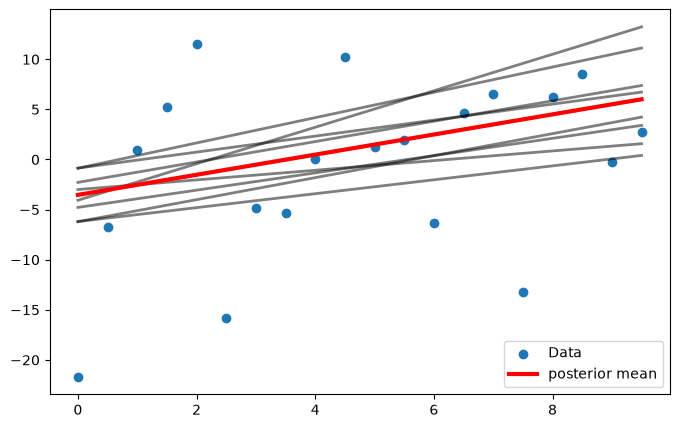

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(x, d, label="Data")

for ys in y_samples:
    plt.plot(x, ys, linewidth= 2.0, color="black", alpha=0.5)

plt.plot(x, y_mean, linewidth= 3.0, color="red", label="posterior mean")
plt.legend()